<a href="https://colab.research.google.com/github/tsubasa-iino/psi4book/blob/main/compchem_book_ch05.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 5章 量子化学計算の基礎について理解を深めよう

### 環境構築

#### Google Colab上にPsi4をインストール

In [1]:
!pip install -q condacolab
import condacolab
import os

# バグ回避パッチ
if "LD_LIBRARY_PATH" not in os.environ:
    os.environ["LD_LIBRARY_PATH"] = ""

print("Installing CondaColab (Base)...")
condacolab.install()

Installing CondaColab (Base)...
⏬ Downloading https://github.com/jaimergp/miniforge/releases/download/24.11.2-1_colab/Miniforge3-colab-24.11.2-1_colab-Linux-x86_64.sh...
📦 Installing...
📌 Adjusting configuration...
🩹 Patching environment...
⏲ Done in 0:00:08
🔁 Restarting kernel...


ランタイム｜セッションを再起動する｜はい を実行。

In [ ]:
import condacolab
import os
import sys

condacolab.check()

# 1. 邪魔なPinningを削除
if os.path.exists("/usr/local/conda-meta/pinned"):
    !rm /usr/local/conda-meta/pinned

# 2. Python 3.12 と Psi4 をインストール（ディスク書き換え）
print("Upgrading Python to 3.12 & Installing Psi4...")
!mamba install -y -q python=3.12 psi4 -c conda-forge/label/libint_dev -c conda-forge

# 3. Pinningの復元（成功環境の再現）
os.makedirs("/usr/local/conda-meta", exist_ok=True)
with open("/usr/local/conda-meta/pinned", "w") as f:
    f.write("python 3.12.*\n")

# 4. 【最重要】カーネルの自殺（強制再起動）
# これにより、メモリ上のPython 3.11を殺し、ディスク上のPython 3.12をロードさせます
print("\n🔄 RESTARTING KERNEL TO LOAD PYTHON 3.12...")
import time
time.sleep(1)
os.kill(os.getpid(), 9)


✨🍰✨ Everything looks OK!
Upgrading Python to 3.12 & Installing Psi4...
Preparing transaction: ...working... done
Verifying transaction: ...working... done
Executing transaction: ...working... done

🔄 RESTARTING KERNEL TO LOAD PYTHON 3.12...


ランタイム｜セッションを再起動する｜はい を実行。

In [1]:
import sys
import os

# パスが通っていなければ通す
target_path = "/usr/local/lib/python3.12/site-packages"
if target_path not in sys.path:
    sys.path.insert(0, target_path)

import psi4
print(f"✅ Restart Successful.")
print(f"Psi4 Version: {psi4.__version__}")
print(f"Python Version: {sys.version.split()[0]}") # ここが3.12になっているはず

# 計算テスト
psi4.set_memory('500 MB')
mol = psi4.geometry("O\nH 1 0.96\nH 1 0.96 2 104.5")
en = psi4.energy('scf/cc-pvdz')
print(f"Energy: {en:.6f}")

✅ Restart Successful.
Psi4 Version: 1.10
Python Version: 3.12.12
Energy: -76.026633


ここまででインストール確認完了。

In [2]:
import os
import datetime
import numpy as np
import pandas as pd
import psi4

print(f'current time: {datetime.datetime.now()}')
print(f'python version:\n{sys.version}')
print(f'numpy version: {np.__version__}')
print(f'pandas version: {pd.__version__}')
print(f'psi4 version: {psi4.__version__}')

current time: 2026-01-14 00:53:03.617282
python version:
3.12.12 (main, Oct 10 2025, 08:52:57) [GCC 11.4.0]
numpy version: 2.0.2
pandas version: 2.2.2
psi4 version: 1.10


#### 必要なライブラリと関数の定義

In [3]:
# 振動数可視化のためのライブラリ
!pip install py3Dmol
import py3Dmol

!git clone https://github.com/duerrsimon/normal-mode-jupyter.git
sys.path.append('/content/normal-mode-jupyter')
from helpers import show_normal_modes

Cloning into 'normal-mode-jupyter'...
remote: Enumerating objects: 23, done.
remote: Counting objects: 100% (23/23), done.
remote: Compressing objects: 100% (19/19), done.
remote: Total 23 (delta 8), reused 17 (delta 4), pack-reused 0 (from 0)
Receiving objects: 100% (23/23), 801.96 KiB | 7.64 MiB/s, done.
Resolving deltas: 100% (8/8), done.


In [5]:
def show_3D(mol: psi4.core.Molecule) -> py3Dmol.view:
    """
    Psi4のMoleculeオブジェクトをpy3Dmolで描画する
    Args:
        mol: 描画対象の分子

    Returns:
        py3Dmol.view: py3Dmolの描画オブジェクト

    """
    view = py3Dmol.view(width=400, height=400)
    xyz = mol.save_string_xyz_file()
    view.addModel(xyz, 'xyz')
    view.setStyle({'stick': {}})
    view.setBackgroundColor('#e1e1e1')
    view.zoomTo()

    return view.show()

#### 計算資源の設定

In [6]:
# 計算資源の確認（CPU, RAM）
!cat /proc/cpuinfo

processor	: 0
vendor_id	: AuthenticAMD
cpu family	: 23
model		: 49
model name	: AMD EPYC 7B12
stepping	: 0
microcode	: 0xffffffff
cpu MHz		: 2249.998
cache size	: 512 KB
physical id	: 0
siblings	: 2
core id		: 0
cpu cores	: 1
apicid		: 0
initial apicid	: 0
fpu		: yes
fpu_exception	: yes
cpuid level	: 13
wp		: yes
flags		: fpu vme de pse tsc msr pae mce cx8 apic sep mtrr pge mca cmov pat pse36 clflush mmx fxsr sse sse2 ht syscall nx mmxext fxsr_opt pdpe1gb rdtscp lm constant_tsc rep_good nopl nonstop_tsc cpuid extd_apicid tsc_known_freq pni pclmulqdq ssse3 fma cx16 sse4_1 sse4_2 x2apic movbe popcnt aes xsave avx f16c rdrand hypervisor lahf_lm cmp_legacy cr8_legacy abm sse4a misalignsse 3dnowprefetch osvw topoext ssbd ibrs ibpb stibp vmmcall fsgsbase tsc_adjust bmi1 avx2 smep bmi2 rdseed adx smap clflushopt clwb sha_ni xsaveopt xsavec xgetbv1 clzero xsaveerptr arat npt nrip_save umip rdpid
bugs		: sysret_ss_attrs null_seg spectre_v1 spectre_v2 spec_store_bypass retbleed smt_rsb srso ibpb

In [7]:
!cat /proc/meminfo

MemTotal:       13286964 kB
MemFree:         7448740 kB
MemAvailable:   11940124 kB
Buffers:          213596 kB
Cached:          4224964 kB
SwapCached:            0 kB
Active:          1396776 kB
Inactive:        3893592 kB
Active(anon):       2720 kB
Inactive(anon):   852492 kB
Active(file):    1394056 kB
Inactive(file):  3041100 kB
Unevictable:           8 kB
Mlocked:               8 kB
SwapTotal:             0 kB
SwapFree:              0 kB
Dirty:               248 kB
Writeback:             0 kB
AnonPages:        851888 kB
Mapped:           542476 kB
Shmem:              3396 kB
KReclaimable:     381872 kB
Slab:             443208 kB
SReclaimable:     381872 kB
SUnreclaim:        61336 kB
KernelStack:        5296 kB
PageTables:        14636 kB
SecPageTables:         0 kB
NFS_Unstable:          0 kB
Bounce:                0 kB
WritebackTmp:          0 kB
CommitLimit:     6643480 kB
Committed_AS:    3063400 kB
VmallocTotal:   34359738367 kB
VmallocUsed:       11784 kB
VmallocChunk:    

In [8]:
n_cpu = os.cpu_count()
ram = os.sysconf('SC_PAGE_SIZE') * os.sysconf('SC_PHYS_PAGES') / (1024 ** 3)

In [9]:
# 環境に応じて計算資源を設定
psi4.set_num_threads(n_cpu)
psi4.set_memory(f'{ram * 0.9: .0f}GB')

11000000000

### 5.3 Psi4のログファイルを見てみよう

In [10]:
# 水分子の構造定義
h2o = psi4.geometry('''
0 1
O       -0.1176269719      0.7387773605      0.0000000000
H        0.8523730281      0.7387773605      0.0000000000
H       -0.4409567836      1.4770262439     -0.5397651517
''')

#### 計算レベルを変える

In [47]:
# HF/STO-3G
psi4.set_output_file('HF_STO-3G.log')
psi4.energy('hf/sto-3g', molecule=h2o)

# MP2/STO-3G
psi4.set_output_file('MP2_STO-3G.log')
psi4.energy('mp2/sto-3g', molecule=h2o)

# B3LYP/STO-3G
psi4.set_output_file('B3LYP_STO-3G.log')
psi4.energy('b3lyp/sto-3g', molecule=h2o)

-75.31258708893922

Google Colabのフォルダにログファイルが生成される

In [40]:
from pathlib import Path
from IPython.display import display, HTML
import html  # 文字のエスケープ用

files = ["HF_STO-3G.log", "MP2_STO-3G.log", "B3LYP_STO-3G.log"]

cols = []
for f in files:
    text = Path(f).read_text()
    cols.append(f"""
        <td style="vertical-align: top;">
          <div style="
              max-height: 500px;
              max-width: 500px;
              overflow: auto;
              white-space: pre;
              font-family: monospace;
              font-size: 11px;">
            <b>{f}</b>
            <br>
            {html.escape(text)}
          </div>
        </td>
    """)

html_str = "<table><tr>" + "\n".join(cols) + "</tr></table>"
display(HTML(html_str))

#### 基底関数系を変える

In [41]:
# HF/6-31G
psi4.set_output_file('HF_6-31G.log')
psi4.energy('hf/6-31g', molecule=h2o)

# HF/6-31G(d)
psi4.set_output_file('HF_6-31Gd.log')
psi4.energy('hf/6-31g(d)', molecule=h2o)

# HF/6-31G(d,p)
psi4.set_output_file('HF_6-31Gdp.log')
psi4.energy('hf/6-31g(d,p)', molecule=h2o)

# HF/6-311G
psi4.set_output_file('HF_6-311G.log')
psi4.energy('hf/6-311g', molecule=h2o)

-76.00974474137101

Google Colabのフォルダにログファイルが生成される

In [48]:
from pathlib import Path
from IPython.display import display, HTML
import html  # 文字のエスケープ用

files = ["HF_STO-3G.log", "HF_6-31G.log", "HF_6-31Gd.log", "HF_6-31Gdp.log", "HF_6-311G.log"]

cols = []
for f in files:
    text = Path(f).read_text()
    cols.append(f"""
        <td style="vertical-align: top;">
          <div style="
              max-height: 500px;
              max-width: 300px;
              overflow: auto;
              white-space: pre;
              font-family: monospace;
              font-size: 11px;">
            <b>{f}</b>
            <br>
            {html.escape(text)}
          </div>
        </td>
    """)

html_str = "<table><tr>" + "\n".join(cols) + "</tr></table>"
display(HTML(html_str))

### 5.4 適切な計算レベルを選択することの大切さを知ろう

In [49]:
import matplotlib as mpl
import matplotlib.pyplot as plt

In [50]:
mpl.style.use('seaborn-v0_8-poster')
mpl.style.use('seaborn-v0_8-whitegrid')

In [51]:
from itertools import product

#### 塩化ナトリウムの計算

In [52]:
def calc_energies(level: str, geom: str, range: np.ndarray) -> list[float]:
    """
    指定範囲内で分子を定義し，指定レベルでエネルギー計算を行う
    Args:
        level: 計算レベル
        geom: 空白{}入りの分子座標
        range: 計算を実行する範囲

    Returns:
        list[float]: エネルギー値のリスト

    """
    energies = []
    for distance in range:
        mol = psi4.geometry(geom.format(distance))
        energy = psi4.energy(level, molecule=mol)
        energies.append(energy)

    return energies

In [57]:
NaCl_geom = '''
0 1
Na  0   0   0
Cl  0   0   {}
'''

methods = ['hf', 'mp2', 'b3lyp']
basis_sets = ['sto-3g', 'cc-pvdz', 'cc-pvtz', 'aug-cc-pvtz']
df_NaCl = pd.DataFrame()  # データフレーム初期化

In [58]:
psi4.set_output_file('NaCl.log')

PosixPath('NaCl.log')

In [59]:
for (method, basis_set) in product(methods, basis_sets):
    level = method + '/' + basis_set
    df_NaCl[level] = calc_energies(level=level,
                                   geom=NaCl_geom,
                                   range=np.arange(1.0, 4.0, 0.1))

In [62]:
df_NaCl.round(3)  # df_NaCl.head().round(3)

,hf/sto-3g,hf/cc-pvdz,hf/cc-pvtz,hf/aug-cc-pvtz,mp2/sto-3g,mp2/cc-pvdz,mp2/cc-pvtz,mp2/aug-cc-pvtz,b3lyp/sto-3g,b3lyp/cc-pvdz,b3lyp/cc-pvtz,b3lyp/aug-cc-pvtz
0,-612.056,-619.248,-619.423,-619.447,-612.099,-619.411,-619.729,-619.766,-613.106,-620.467,-620.638,-620.659
1,-612.729,-619.874,-619.988,-620.002,-612.772,-620.038,-620.287,-620.320,-613.778,-621.092,-621.202,-621.216
2,-613.247,-620.303,-620.378,-620.386,-613.289,-620.466,-620.668,-620.699,-614.288,-621.518,-621.590,-621.597
3,-613.644,-620.619,-620.672,-620.676,-613.685,-620.779,-620.952,-620.983,-614.673,-621.827,-621.878,-621.881
4,-613.935,-620.860,-620.901,-620.903,-613.977,-621.016,-621.170,-621.202,-614.955,-622.058,-622.097,-622.099
5,-614.141,-621.041,-621.074,-621.076,-614.184,-621.194,-621.335,-621.366,-615.155,-622.229,-622.262,-622.264
6,-614.284,-621.172,-621.201,-621.202,-614.328,-621.324,-621.457,-621.483,-615.293,-622.353,-622.382,-622.383
7,-614.382,-621.265,-621.291,-621.292,-614.426,-621.416,-621.543,-621.564,-615.387,-622.440,-622.466,-622.468
8,-614.446,-621.330,-621.353,-621.354,-614.490,-621.479,-621.602,-621.619,-615.448,-622.499,-622.525,-622.526
9,-614.487,-621.373,-621.394,-621.395,-614.531,-621.522,-621.642,-621.656,-615.487,-622.539,-622.563,-622.565


<Axes: >

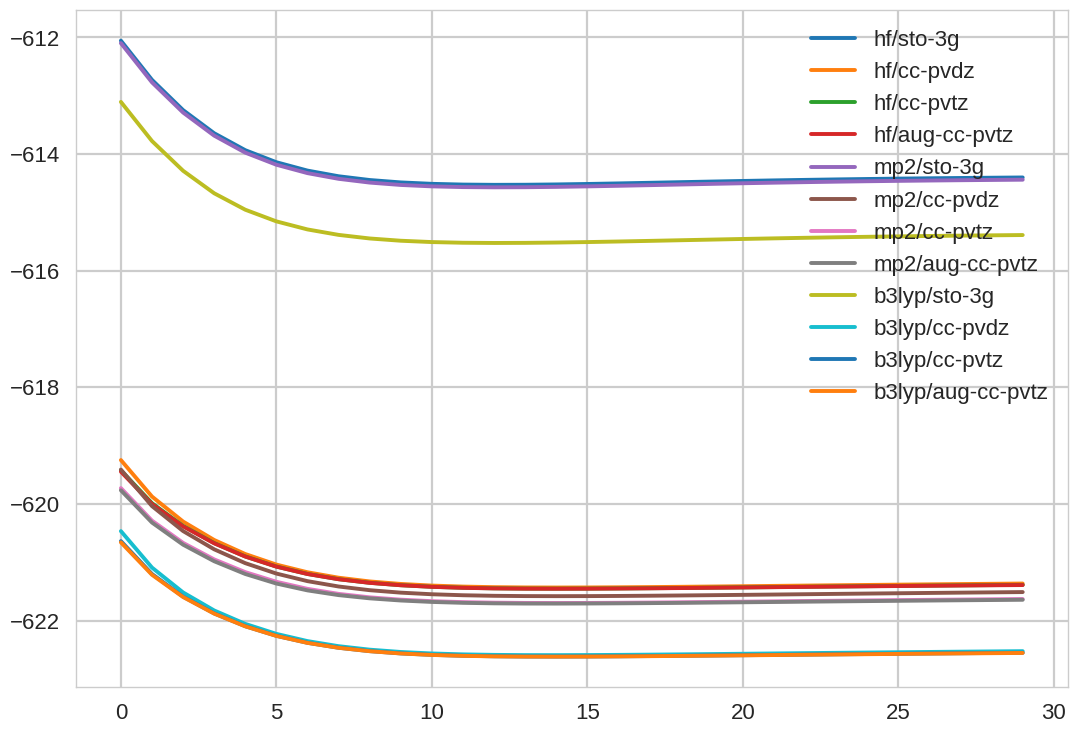

In [63]:
df_NaCl.plot()

##### グラフの作成

In [66]:
x = np.arange(1.0, 4.0, 0.1)
fs = 24  # fontsize

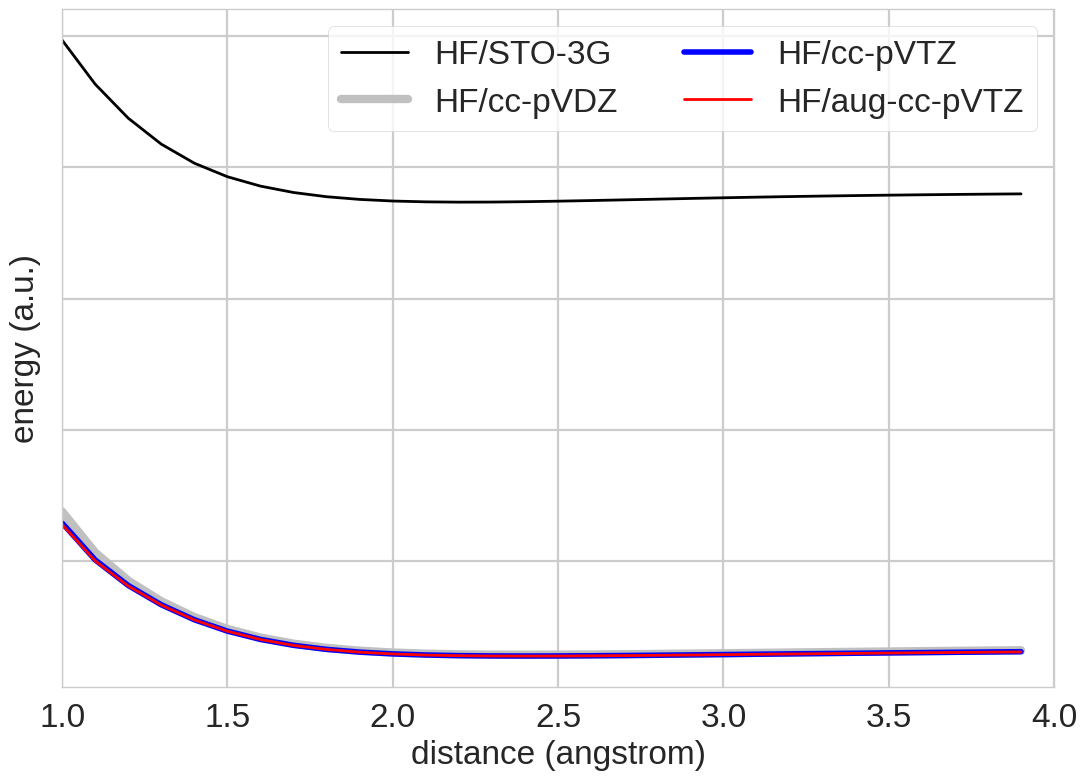

In [82]:
# HF
fig = plt.figure()
ax = fig.add_subplot(111)

ax.plot(x, df_NaCl['hf/sto-3g'], color='black', lw=2, label='HF/STO-3G')
ax.plot(x, df_NaCl['hf/cc-pvdz'], color='silver', lw=6, label='HF/cc-pVDZ')
ax.plot(x, df_NaCl['hf/cc-pvtz'], color='blue', lw=4, label='HF/cc-pVTZ')
ax.plot(x, df_NaCl['hf/aug-cc-pvtz'], color='red', lw=2, label='HF/aug-cc-pVTZ')  # プロットが重なるので線幅調整

ax.set_xlim(1.0, 4.0)
ax.set_xticks(np.arange(1.0, 4.1, 0.5))
ax.set_xticklabels(np.arange(1.0, 4.1, 0.5), fontsize=fs)
ax.set_yticklabels([])
ax.set_xlabel('distance (angstrom)', size=fs)
ax.set_ylabel('energy (a.u.)', size=fs)

ax.legend(fontsize=fs, ncol=2, frameon=True)
fig.savefig('NaCl_HF_24.png', dpi=600, transparent=True)

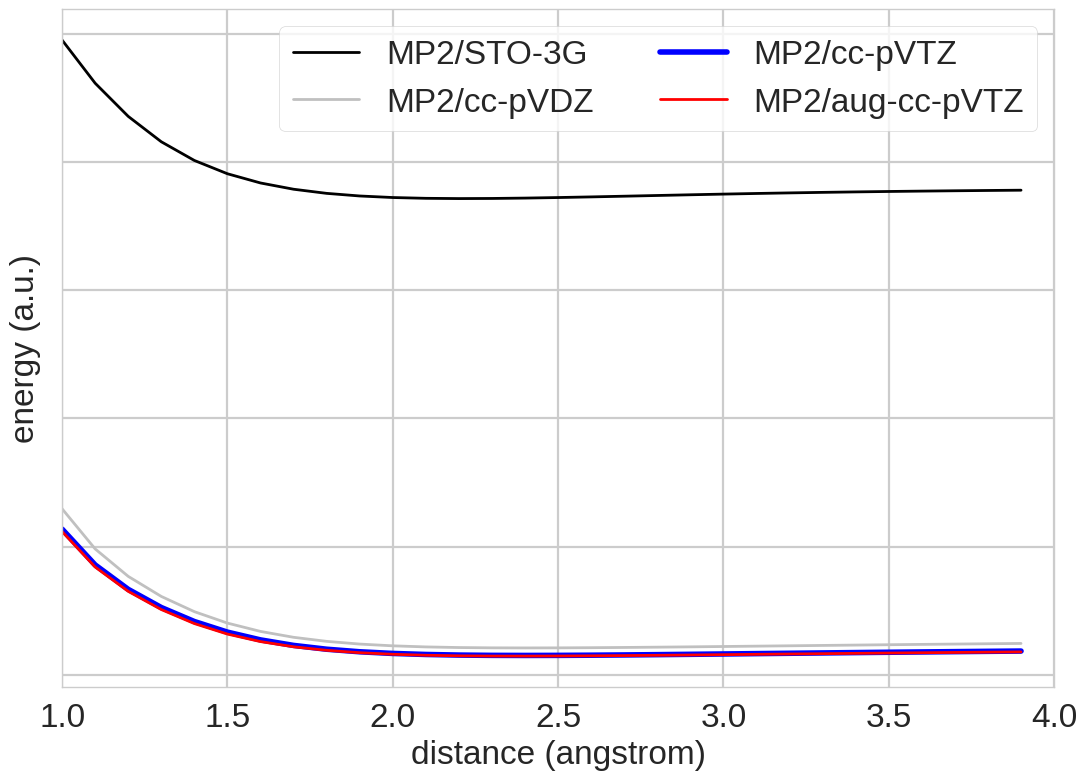

In [84]:
# MP2
fig = plt.figure()
ax = fig.add_subplot(111)

ax.plot(x, df_NaCl['mp2/sto-3g'], color='black', lw=2, label='MP2/STO-3G')
ax.plot(x, df_NaCl['mp2/cc-pvdz'], color='silver', lw=2, label='MP2/cc-pVDZ')
ax.plot(x, df_NaCl['mp2/cc-pvtz'], color='blue', lw=4, label='MP2/cc-pVTZ')
ax.plot(x, df_NaCl['mp2/aug-cc-pvtz'], color='red', lw=2, label='MP2/aug-cc-pVTZ')

ax.set_xlim(1.0, 4.0)
ax.set_xticks(np.arange(1.0, 4.1, 0.5))
ax.set_xticklabels(np.arange(1.0, 4.1, 0.5), fontsize=fs)
ax.set_yticklabels([])
ax.set_xlabel('distance (angstrom)', size=fs)
ax.set_ylabel('energy (a.u.)', size=fs)

ax.legend(fontsize=fs, ncol=2, frameon=True)
fig.savefig('NaCl_MP2_24.png', dpi=600, transparent=True)

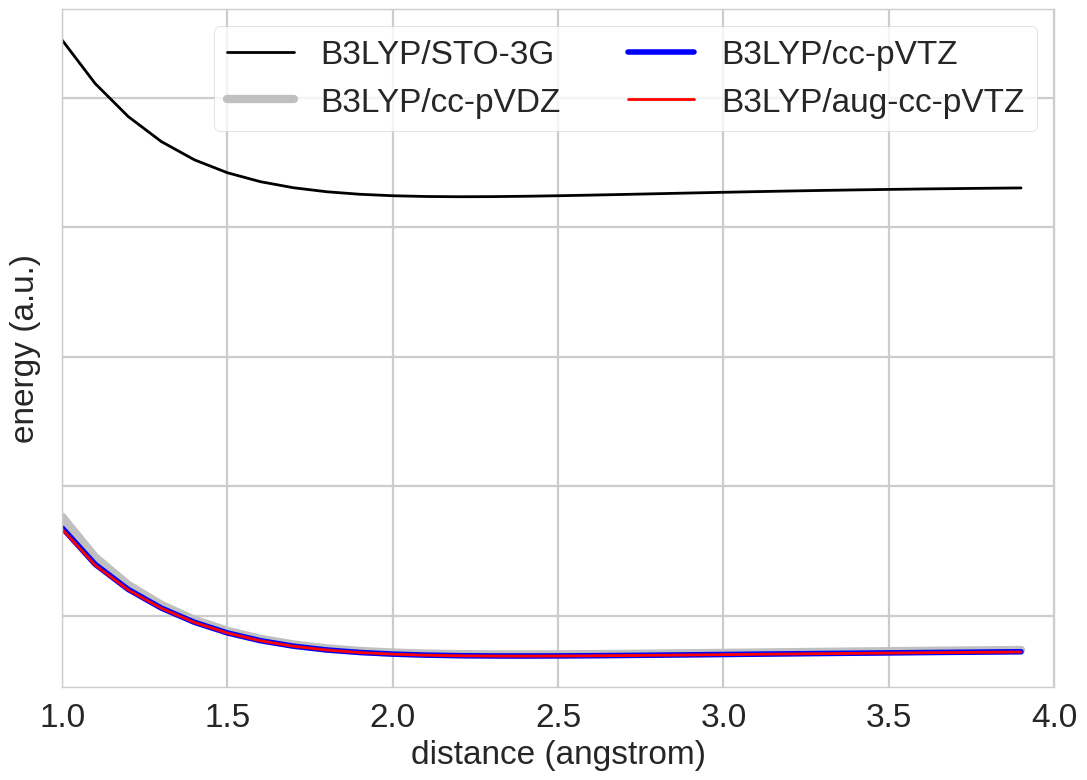

In [85]:
# B3LYP
fig = plt.figure()
ax = fig.add_subplot(111)

ax.plot(x, df_NaCl['b3lyp/sto-3g'], color='black', lw=2, label='B3LYP/STO-3G')
ax.plot(x, df_NaCl['b3lyp/cc-pvdz'], color='silver', lw=6, label='B3LYP/cc-pVDZ')
ax.plot(x, df_NaCl['b3lyp/cc-pvtz'], color='blue', lw=4, label='B3LYP/cc-pVTZ')
ax.plot(x, df_NaCl['b3lyp/aug-cc-pvtz'], color='red', lw=2, label='B3LYP/aug-cc-pVTZ')

ax.set_xlim(1.0, 4.0)
ax.set_xticks(np.arange(1.0, 4.1, 0.5))
ax.set_xticklabels(np.arange(1.0, 4.1, 0.5), fontsize=fs)
ax.set_yticklabels([])
ax.set_xlabel('distance (angstrom)', size=fs)
ax.set_ylabel('energy (a.u.)', size=fs)

ax.legend(fontsize=fs, ncol=2, frameon=True)
fig.savefig('NaCl_B3LYP_24.png', dpi=600, transparent=True)

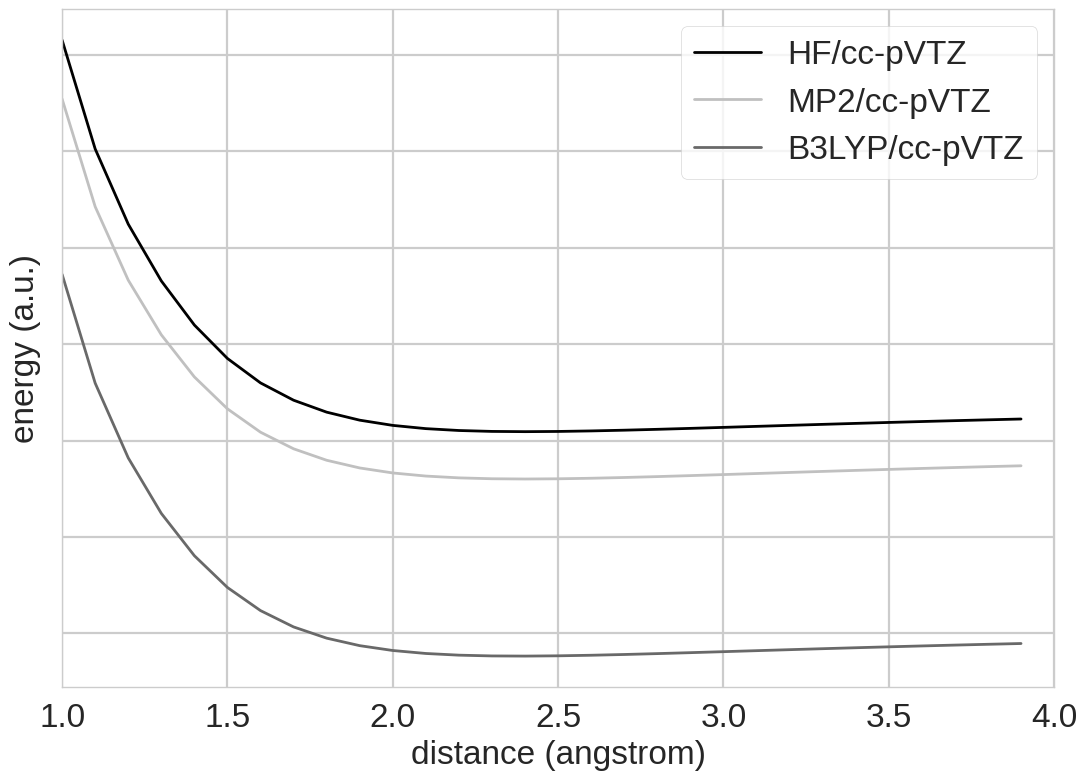

In [86]:
## cc-pVTZ
fig = plt.figure()
ax = fig.add_subplot(111)

ax.plot(x, df_NaCl['hf/cc-pvtz'], color='black', lw=2, label='HF/cc-pVTZ')
ax.plot(x, df_NaCl['mp2/cc-pvtz'], color='silver', lw=2, label='MP2/cc-pVTZ')
ax.plot(x, df_NaCl['b3lyp/cc-pvtz'], color='dimgray', lw=2, label='B3LYP/cc-pVTZ')

ax.set_xlim(1.0, 4.0)
ax.set_xticks(np.arange(1.0, 4.1, 0.5))
ax.set_xticklabels(np.arange(1.0, 4.1, 0.5), fontsize=fs)
ax.set_yticklabels([])
ax.set_xlabel('distance (angstrom)', size=fs)
ax.set_ylabel('energy (a.u.)', size=fs)

ax.legend(fontsize=fs, frameon=True)
fig.savefig('NaCl_cc-pVTZ_24.png', dpi=600, transparent=True)

##### エネルギー極小値を求める

In [87]:
def get_minima(theory: str,
               geom: str,
               distance_min: float,
               distance_max: float) -> float:
    """
    探索範囲内でエネルギー最小値を与える原子間距離を求める。

    Args:
        theory: 計算レベル
        geom: 計算対象分子の構造
        distance_min: 探索する最短原子間距離
        distance_max: 探索する最長原子間距離

    Returns:
        float: エネルギー最小値を与える原子間距離
    """
    from scipy import optimize

    level = f'{theory}/cc-pvtz'


    def object_function(length: float) -> float:
        """
        最小化する目的関数。指定原子間距離でエネルギー計算を行う。

        Args:
            length: 原子間距離
        Returns:
            float: エネルギー値
        """
        mol = psi4.geometry(geom.format(length))
        energy = psi4.energy(level, molecule=mol)

        return energy


    distance = optimize.fminbound(object_function,
                                  x1=distance_min,
                                  x2=distance_max)

    return distance

In [94]:
psi4.set_output_file('NaCl_minima.log')

PosixPath('NaCl_minima.log')

In [90]:
for method in methods:
    dist = get_minima(method, NaCl_geom, 1.0, 4.0)
    print(f'{method.upper()}/cc-pVTZ: {dist: .2f} angstrom')

HF/cc-pVTZ:  2.40 angstrom
MP2/cc-pVTZ:  2.40 angstrom
B3LYP/cc-pVTZ:  2.38 angstrom


#### アルゴン二量体の計算

In [96]:
!mamba install -y -c conda-forge dftd3-python
# 下記の計算でPython module 'dftd3' not found in envvar PYTHONPATH. Please install a dftd3 version with enabled Python API (e.g. conda install dftd3-python -c conda-forge)
# と怒られるのでインストールしておく

[+] 0.0s
[+] 0.0s
[+] 0.1s
conda-forge/linux-64  ⣾  
conda-forge/noarch    ⣾  [+] 0.2s
conda-forge/linux-64   2%
conda-forge/noarch     7%[+] 0.3s
conda-forge/linux-64   5%
conda-forge/noarch    10%[+] 0.4s
conda-forge/linux-64   6%
conda-forge/noarch    17%[+] 0.5s
conda-forge/linux-64  10%
conda-forge/noarch    25%[+] 0.6s
conda-forge/linux-64  14%
conda-forge/noarch    28%[+] 0.7s
conda-forge/linux-64  16%
conda-forge/noarch    34%[+] 0.8s
conda-forge/linux-64  18%
conda-forge/noarch    40%[+] 0.9s
conda-forge/linux-64  21%
conda-forge/noarch    46%[+] 1.0s
conda-forge/linux-64  23%
conda-forge/noarch    52%[+] 1.1s
conda-forge/linux-64  26%
conda-forge/noarch    55%[+] 1.2s
conda-forge/linux-64  28%
conda-forge/noarch    61%[+] 1.3s
conda-forge/linux-64  31%
conda-forge/noarch    66%[+] 1.4s
conda-forge/linux-64  33%
conda-forge/noarch    69%[+] 1.5s
conda-forge/linux-64  36%
conda-forge/noarch    75%[+] 1.6s
conda-forge/linux-64  37%
conda-forge/noarch    81%[+] 1.7s
conda-forge/l

In [97]:
Ar2_geom = '''
0 1
Ar  0   0   0
Ar  0   0   {}
'''

methods = ['mp2', 'b3lyp', 'b3lyp-d3bj', 'wb97x-d']
df_ar2 = pd.DataFrame()

In [98]:
psi4.set_output_file('Ar2.log')

PosixPath('Ar2.log')

In [99]:
for method in methods:
    level = method + '/cc-pvtz'
    df_ar2[method] = calc_energies(level=level,
                                   geom=Ar2_geom,
                                   range=np.arange(1.5, 5.5, 0.1))

In [101]:
df_ar2.round(3)

,mp2,b3lyp,b3lyp-d3bj,wb97x-d
0,-1053.276,-1054.303,-1054.305,-1054.272
1,-1053.489,-1054.512,-1054.514,-1054.483
2,-1053.651,-1054.671,-1054.672,-1054.643
3,-1053.772,-1054.790,-1054.792,-1054.762
4,-1053.863,-1054.880,-1054.881,-1054.852
5,-1053.930,-1054.946,-1054.948,-1054.918
6,-1053.979,-1054.995,-1054.996,-1054.966
7,-1054.015,-1055.030,-1055.032,-1055.002
8,-1054.041,-1055.056,-1055.057,-1055.028
9,-1054.059,-1055.074,-1055.076,-1055.046


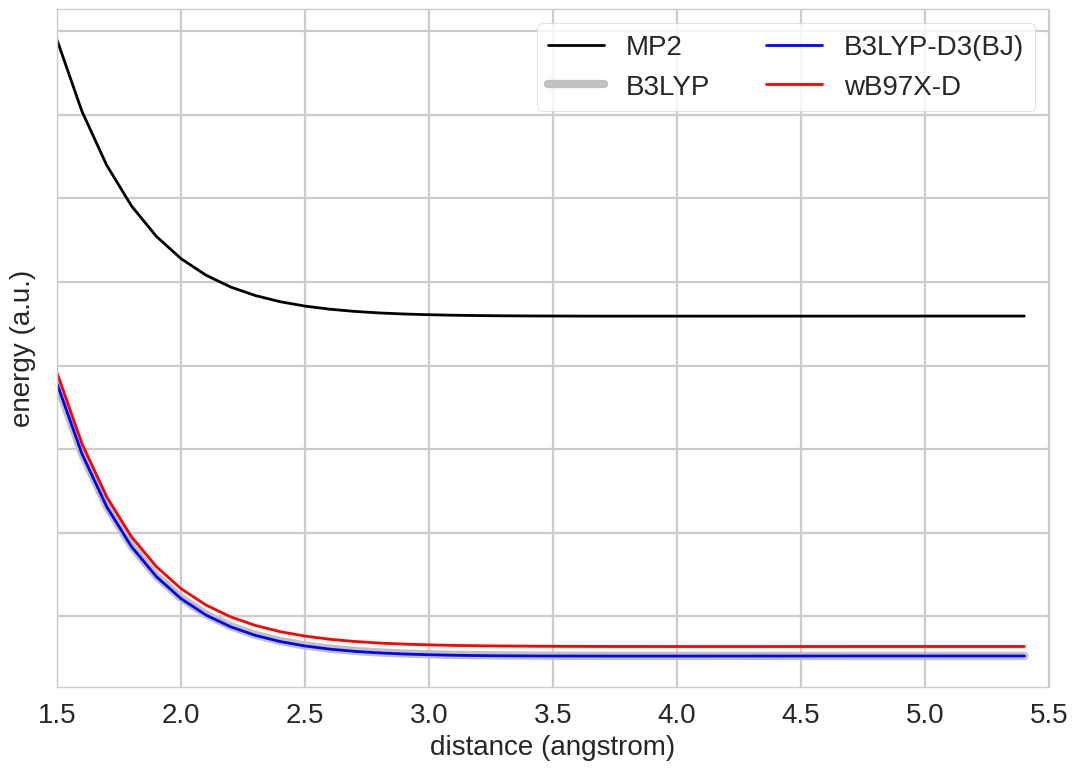

In [106]:
fig = plt.figure()
ax = fig.add_subplot(111)

ax.plot(np.arange(1.5, 5.5, 0.1), df_ar2['mp2'], '-', color='black',linewidth=2, label='MP2')
ax.plot(np.arange(1.5, 5.5, 0.1), df_ar2['b3lyp'], '-', color='silver', linewidth=6, label='B3LYP')
ax.plot(np.arange(1.5, 5.5, 0.1), df_ar2['b3lyp-d3bj'], '-', color='blue', linewidth=2, label='B3LYP-D3(BJ)')
ax.plot(np.arange(1.5, 5.5, 0.1), df_ar2['wb97x-d'], '-', color='red', linewidth=2, label='wB97X-D')

ax.set_xlim(1.5, 5.5)
ax.set_xticks(np.arange(1.5, 5.6, 0.5))
ax.set_xticklabels(np.arange(1.5, 5.6, 0.5), fontsize=20)
ax.set_yticklabels([])
ax.set_xlabel('distance (angstrom)', size=20)
ax.set_ylabel('energy (a.u.)', size=20)
ax.legend(fontsize=20, ncol=2, frameon=True)
fig.savefig('Ar2_energy_20.png', dpi=600, transparent=True)

##### エネルギー極小値を求める

In [107]:
psi4.set_output_file('Ar2_minima.log')

PosixPath('Ar2_minima.log')

In [108]:
for method in methods:
    dist = get_minima(method, Ar2_geom, 1.5, 5.5)
    print(f'{method.upper()}/cc-pVTZ: {dist: .2f} angstrom')

MP2/cc-pVTZ:  3.93 angstrom
B3LYP/cc-pVTZ:  5.50 angstrom
B3LYP-D3BJ/cc-pVTZ:  3.80 angstrom
WB97X-D/cc-pVTZ:  4.18 angstrom


In [109]:
psi4.energy('mp2/cc-pvtz', molecule=psi4.geometry(Ar2_geom.format(3.934)))

-1054.1021026039698

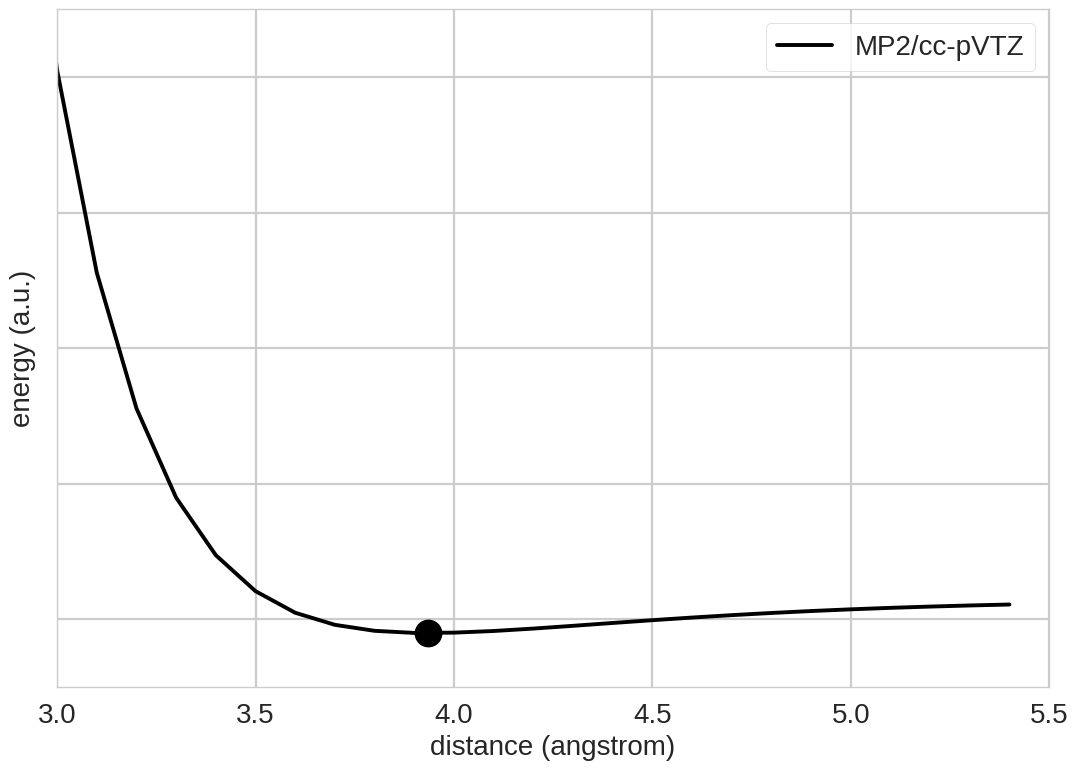

In [110]:
fig = plt.figure()
ax = fig.add_subplot(111)

ax.plot(np.arange(1.5, 5.5, 0.1), df_ar2['mp2'], 'k-', label='MP2/cc-pVTZ')
ax.plot(3.934, -1054.1021026, 'ko', ms=20)
ax.set_xlim(3.0, 5.5)
ax.set_xticks(np.arange(3, 5.6, 0.5))
ax.set_xticklabels(np.arange(3, 5.6, 0.5), fontsize=20)
ax.set_ylim(-1054.1025, -1054.0975)
ax.set_yticklabels([])
ax.set_xlabel('distance (angstrom)', size=20)
ax.set_ylabel('energy (a.u.)', size=20)
ax.legend(fontsize=20, frameon=True)

fig.savefig('Ar2_mp2_20.png', dpi=600, transparent=True)